In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data/customer_data.csv")
df.head()

Matplotlib is building the font cache; this may take a moment.


,customer_id,signup_date,age,gender,city,segment,income,purchase_amount,satisfaction_score
0,1358,2023-11-11 12:41:50.621242,45.0,F,Hyderabad,SME,72734.20,2169.40,1.0
1,1338,2023-09-14 00:17:18.877755,35.0,male,Hyderabad,retail,26311.75,4602.50,2.0
2,1328,2023-08-15 18:05:03.006012,34.0,F,Bangalore,retail,50911.09,1138.96,1.0
3,1014,2021-02-08 00:51:56.633266,55.0,M,Mumbai,Retail,39434.56,645.32,2.0
4,1419,2024-05-08 00:08:39.438877,47.0,Male,Mumbai,SME,64738.33,1674.65,4.0


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 505 entries, 0 to 504
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         505 non-null    int64  
 1   signup_date         495 non-null    str    
 2   age                 485 non-null    float64
 3   gender              505 non-null    str    
 4   city                505 non-null    str    
 5   segment             505 non-null    str    
 6   income              445 non-null    float64
 7   purchase_amount     505 non-null    float64
 8   satisfaction_score  490 non-null    float64
dtypes: float64(4), int64(1), str(4)
memory usage: 35.6 KB


In [3]:
df.describe(include='all')

,customer_id,signup_date,age,gender,city,segment,income,purchase_amount,satisfaction_score
count,505.000000,495,485.000000,505,505,505,4.450000e+02,505.000000,490.000000
unique,NaN,490,NaN,5,10,4,NaN,NaN,NaN
top,NaN,2024-11-02 11:35:28.256513,NaN,F,Hyderabad,SME,NaN,NaN,NaN
freq,NaN,2,NaN,115,70,135,NaN,NaN,NaN
mean,1250.463366,NaN,37.024742,NaN,NaN,NaN,1.242810e+05,3026.222574,2.926531
std,144.714028,NaN,16.506554,NaN,NaN,NaN,8.151501e+05,2076.182829,1.422400
min,1001.000000,NaN,-5.000000,NaN,NaN,NaN,1.233507e+04,143.820000,1.000000
25%,1124.000000,NaN,29.000000,NaN,NaN,NaN,3.606584e+04,1492.200000,2.000000
50%,1251.000000,NaN,36.000000,NaN,NaN,NaN,5.097927e+04,2503.360000,3.000000
75%,1374.000000,NaN,43.000000,NaN,NaN,NaN,7.200196e+04,4127.750000,4.000000


In [4]:
(df.isna().sum() / len(df) * 100).round(2)

customer_id            0.00
signup_date            1.98
age                    3.96
gender                 0.00
city                   0.00
segment                0.00
income                11.88
purchase_amount        0.00
satisfaction_score     2.97
dtype: float64

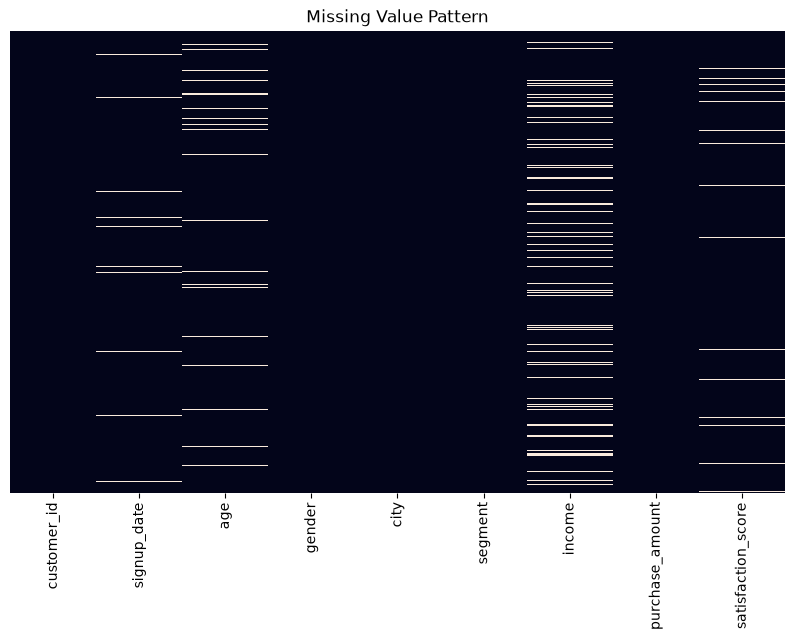

In [5]:
plt.figure(figsize=(10,6))
sns.heatmap(df.isna(), cbar=False, yticklabels=False)
plt.title("Missing Value Pattern")
plt.show()

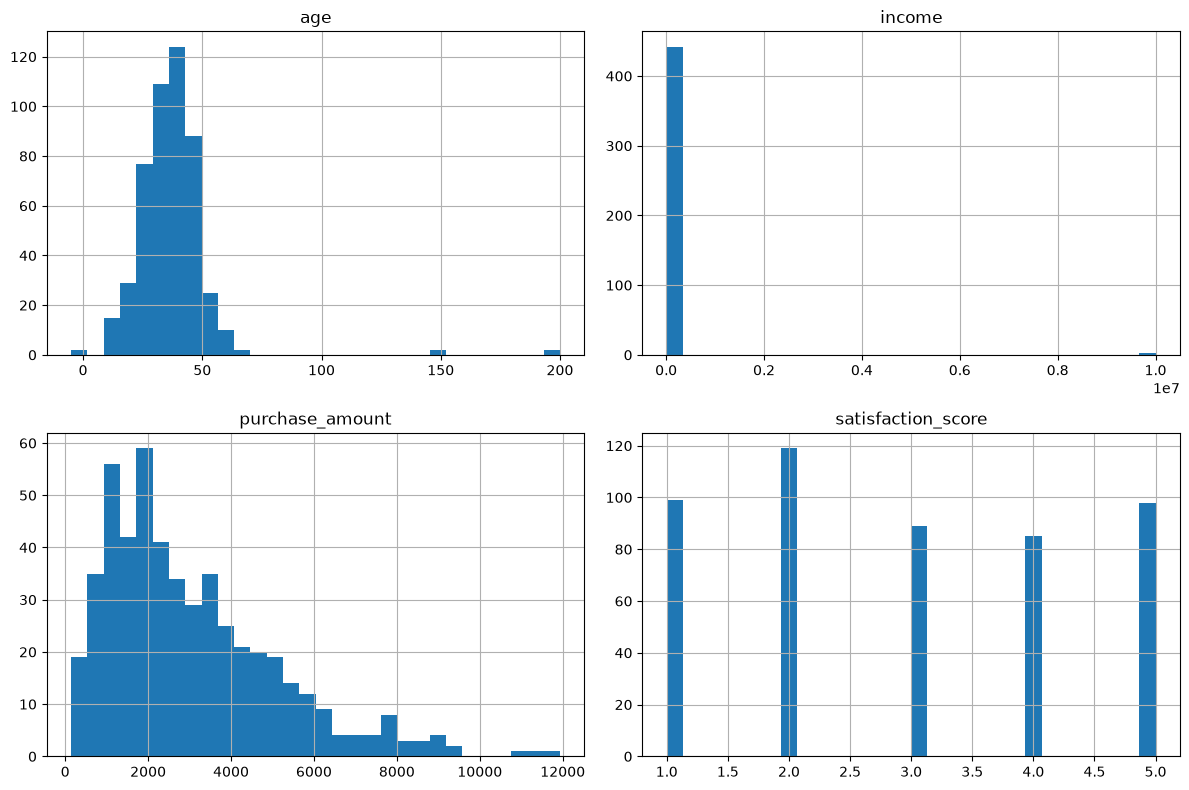

In [6]:
df[['age', 'income', 'purchase_amount', 'satisfaction_score']].hist(figsize=(12,8), bins=30)
plt.tight_layout()
plt.show()

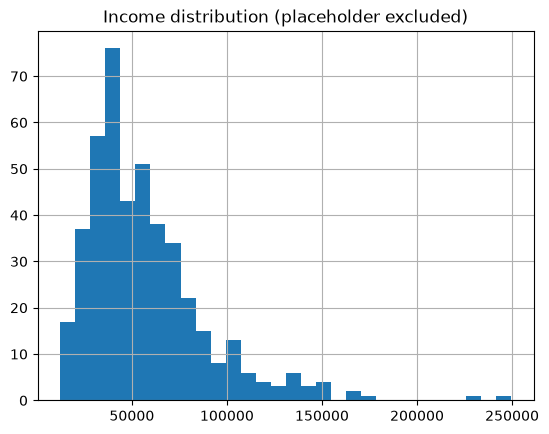

In [7]:
df[df['income'] < 1000000]['income'].hist(bins=30)
plt.title("Income distribution (placeholder excluded)")
plt.show()

In [8]:
df.duplicated().sum()

np.int64(5)

In [9]:
df['customer_id'].duplicated().sum()
df['customer_id'].is_unique

False

In [10]:
df['customer_id'].duplicated().sum()

np.int64(13)

In [11]:
df[df['customer_id'].duplicated(keep=False)].sort_values('customer_id')

,customer_id,signup_date,age,gender,city,segment,income,purchase_amount,satisfaction_score
21,1048,2021-05-18 12:21:38.597194,12.0,F,Bengaluru,Retail,37942.80,2203.97,5.0
407,1048,2021-05-18 12:21:38.597194,12.0,F,Bengaluru,Retail,37942.80,2203.97,5.0
501,1068,2021-07-16 00:46:10.340681,42.0,F,Delhi,SME,35812.12,6233.74,2.0
27,1068,2021-07-16 00:46:10.340681,42.0,F,Delhi,SME,35812.12,6233.74,2.0
193,1073,2021-08-02 14:05:31.863727,31.0,F,delhi,SME,88156.02,1811.50,5.0
493,1073,2021-07-30 15:52:18.276553,9.0,M,Pune,Retail,30907.17,3374.13,3.0
498,1104,2021-10-29 08:42:19.478957,37.0,male,Mumbai,Corporate,59350.79,5217.39,4.0
195,1104,2021-11-01 06:55:33.066132,46.0,F,delhi,retail,38386.17,2234.82,4.0
396,1124,2021-12-29 19:20:04.809619,36.0,M,Mumbai,Retail,94257.85,1199.06,2.0
420,1124,NaN,19.0,Male,Mumbai,retail,42116.36,2841.61,1.0


df['city'].value_counts()

In [13]:
df['gender'].value_counts()

gender
F         115
male      105
M         102
Female    100
Male       83
Name: count, dtype: int64

In [14]:
df['segment'].value_counts()

segment
SME          135
Corporate    135
retail       118
Retail       117
Name: count, dtype: int64

## Data Quality Audit — customer_data.csv

| Column | Issue | Severity | Proposed Fix |
|---|---|---|---|
| income | 60 missing (11.88%) | High | Investigate; consider median imputation or flag-and-exclude |
| income | Extreme outlier (~10,000,000) on a few rows, distorting mean/std | High | Treat as invalid/placeholder; convert to NaN |
| customer_id | Same ID reused on different-looking records (e.g. 1073, 1104, 1124, 1155) — breaks primary-key uniqueness | High | Investigate source system; may need to assign new IDs or flag affected rows before any per-customer analysis |
| customer_id / full rows | 5 fully identical duplicate rows | Medium | Drop exact duplicates |
| age | 20 missing (3.96%) | Medium | Consider median imputation |
| age | Outliers: min -5, max 200 (impossible values) | Medium-High | Treat as data entry errors; cap, correct, or set to NaN |
| signup_date | 10 missing (1.98%) | Low-Medium | Investigate source; consider leaving as NaN if unrecoverable |
| signup_date | Stored as text (object), not datetime | Medium | Convert with `pd.to_datetime()` |
| satisfaction_score | 15 missing (2.97%) | Low | Consider median/mode imputation |
| city | 10 labels instead of 7 (Delhi/delhi, Bangalore/Bengaluru, Mumbai/"Mumbai ") | Medium | Standardize via `.str.strip().str.title()` + mapping dict for Bengaluru→Bangalore |
| gender | 5 labels instead of 2 (F/Female, M/Male/male) | Low-Medium | Standardize via mapping dict |
| segment | 4 labels instead of 3 (Retail/retail) | Low | Standardize via `.str.title()` |

**Missingness pattern:** Scattered/random across rows for signup_date, age, income, satisfaction_score — no clustering observed, suggesting missing-at-random rather than a systemic collection failure. Standard imputation should be safe in the cleaning phase.